In [18]:
from HARey_constellation_cards.harey_main import HAReyMain
from matplotlib.font_manager import FontProperties

# Read the constellations file, the HIP catalogue and the object names
harey = HAReyMain(language='IAU-EN', star_colors='helland')




Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at cardbacks/tarot_round.png


In [2]:
# Set two custom fonts for the plots and the cards names
harey.set_fonts({'labels': FontProperties(fname = 'fonts/PatrickHand-Regular.ttf')})

In [3]:
harey.set_limiting_magnitude(6.5)

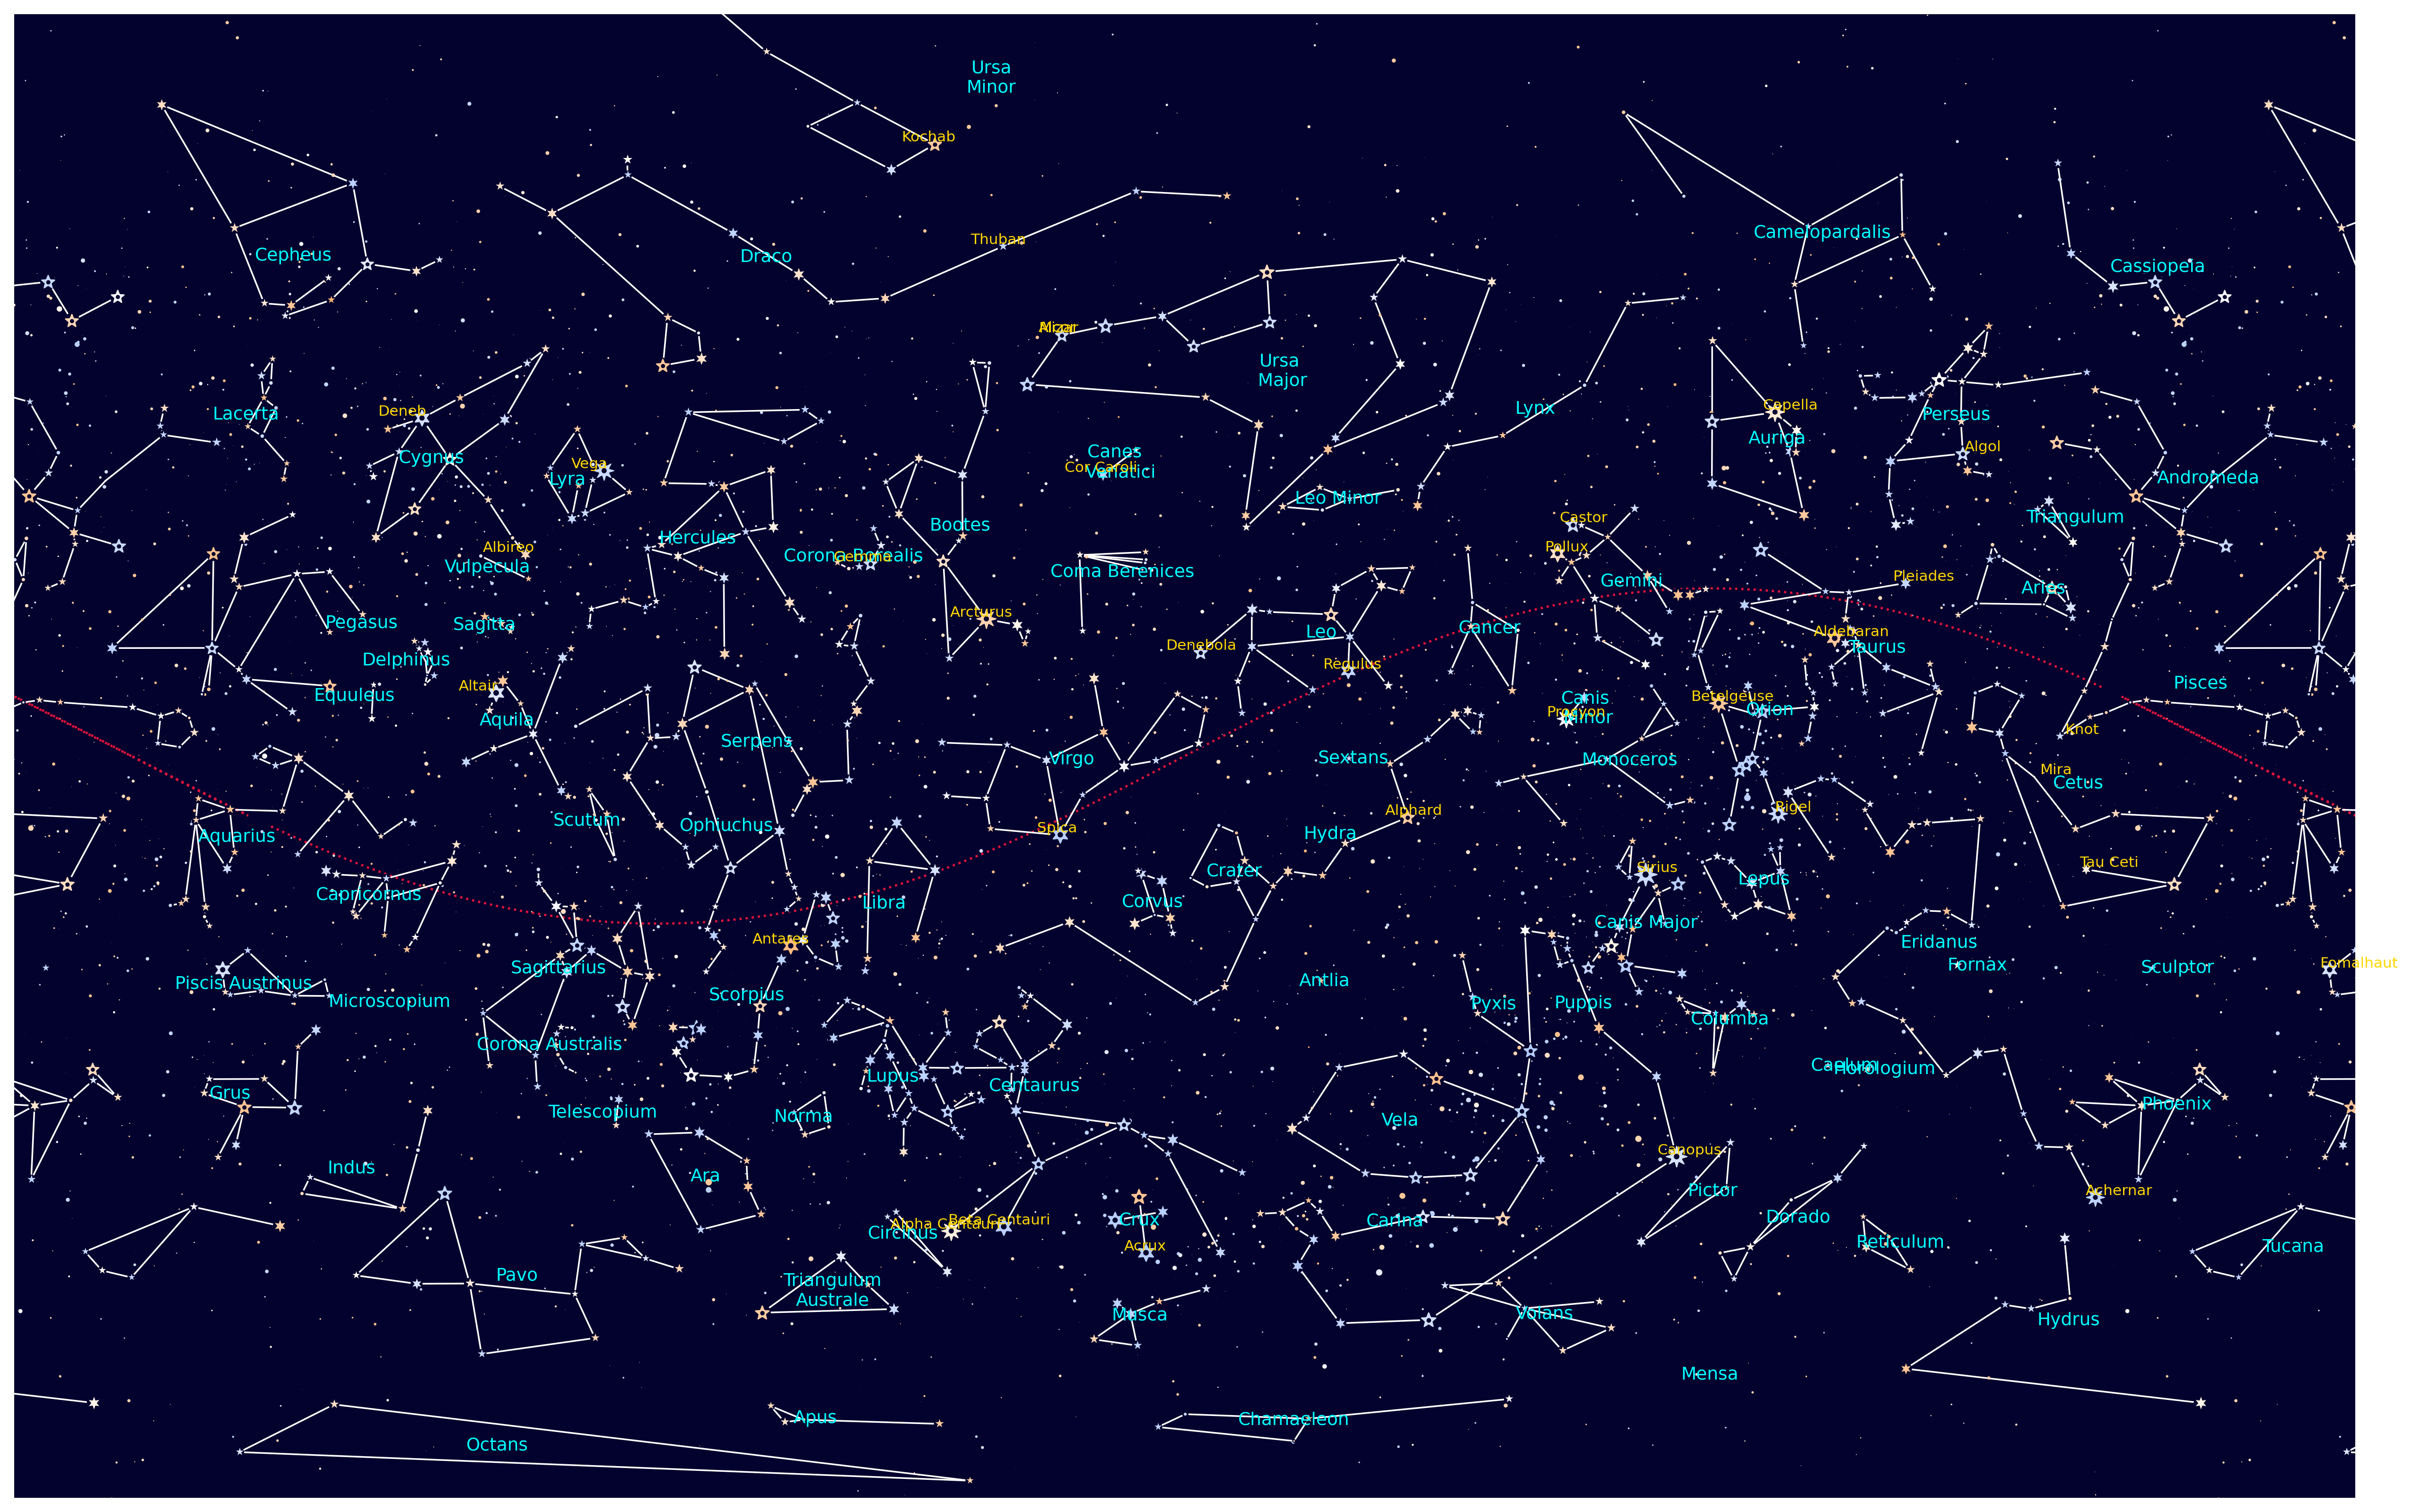

In [19]:
harey.set_flags({'CON_LINES':True, 'CON_NAMES':True, 'SIS_SCRIPT':True, 'STAR_COLORS':True, 'STAR_NAMES':True})
harey.equatorial_map(max_dims=(16.5,11), font_sizes=(5,6), star_size=10, dec_FOV=170)
#harey.polar_map(figsize=8, star_size=200, font_sizes=(10,14))

In [20]:
'Cap' in harey.constellation_ids

True

In [22]:
harey.set_limiting_magnitude(6)
harey.set_card_template('poker-square')
harey.set_colors({'sky':'white', 'star':'black', 'constellations':'black'})


for id in ['Ori', 'Per', 'Lup', 'Gru', 'Tuc', 'Lep', 
           'Lac', 'Aql', 'Cep', 'Mon', 'Dor', 'Leo',
           'Pav', 'Gem', 'Cap', 'Lib', 'Sco', 'Boo' ]:
    harey.set_flags({'CON_LINES':True, 'SHOW':False})
    harey.plot_card(id, BEST_AR=True, save_name=f'VDB/{id}.png')

Using the poker-square format, 2.50x3.50 in, using the template at cardbacks/poker_square.png


In [ ]:
from fpdf import FPDF
import os

pdf = FPDF(orientation="P", unit="in", format="A4")
files = os.listdir('VDB')
cards = [file for file in files if file.endswith('.png')]
cards.sort() # Sort the cards alphabetically

cw, ch = harey.width, harey.height    # Card width, card height
cwb, chb = cw  , ch   # card width and height with bleed
# distance from the page margin
grid = 3
margin_w = (pdf.w - grid*cwb)/2
margin_h = (pdf.h - grid*chb)/2

for i in range(2):
        pdf.add_page()
        for i in range(1, grid):
            pdf.line(0, margin_h + i*chb, pdf.w,  margin_h + i*chb)
            pdf.line(margin_w + i*cwb, 0, margin_w + i*cwb, pdf.h)

for i, card in enumerate(cards):
    pdf.page = 1 + i//9
    x = i%grid
    y = (i%(grid*grid))//grid
    pdf.image(f'VDB/{card}', margin_w + x*cwb , margin_h + y*chb, cw, ch)

bleed = 0
# draw the helpers only on the cardbacks pages (fronts are joined together by the bleed)
for page in range(1, 2+1, 2):
    pdf.page = page       
    pdf.set_draw_color(100)

    for i in range(grid):
        # Left margin lines
        pdf.line(0, margin_h + i*chb + bleed, 0.8*margin_w, margin_h + i*chb + bleed)
        pdf.line(0, margin_h + i*chb + bleed + ch, 0.8*margin_w, margin_h + i*chb + bleed + ch)

        # Right margin lines
        pdf.line(pdf.w, margin_h + i*chb + bleed, pdf.w - 0.8*margin_w, margin_h + i*chb + bleed)
        pdf.line(pdf.w, margin_h + i*chb + bleed + ch, pdf.w - 0.8*margin_w, margin_h + i*chb + bleed + ch)

        # Top margin lines
        pdf.line(margin_w + i*cwb + bleed, 0 , margin_w + i*cwb + bleed, 0.8*margin_h)
        pdf.line(margin_w + i*cwb + bleed + cw, 0 , margin_w + i*cwb + bleed + cw, 0.8*margin_h)

        # Bottom margin lines
        pdf.line(margin_w + i*cwb + bleed, pdf.h , margin_w + i*cwb + bleed, pdf.h - 0.8*margin_h)
        pdf.line(margin_w + i*cwb + bleed + cw, pdf.h , margin_w + i*cwb + bleed + cw, pdf.h - 0.8*margin_h)

    # Internal helpers
    for i in range(grid+1):
        for j in range(grid):
            pdf.line(margin_w + i*cwb - 0.8*bleed, margin_h + j*chb + bleed, margin_w + i*cwb + 0.8*bleed, margin_h + j*chb + bleed)
            pdf.line(margin_w + i*cwb - 0.8*bleed, margin_h + j*chb + bleed + ch, margin_w + i*cwb + 0.8*bleed, margin_h + j*chb + bleed + ch)

    for i in range(grid):
        for j in range(grid+1):
            pdf.line(margin_w + i*cwb + bleed, margin_h + j*chb - 0.8*bleed, margin_w + i*cwb + bleed, margin_h + j*chb + 0.8*bleed)
            pdf.line(margin_w + i*cwb + bleed + cw, margin_h + j*chb - 0.8*bleed, margin_w + i*cwb + bleed + cw, margin_h + j*chb + 0.8*bleed)
        

pdf.output('cards.pdf')


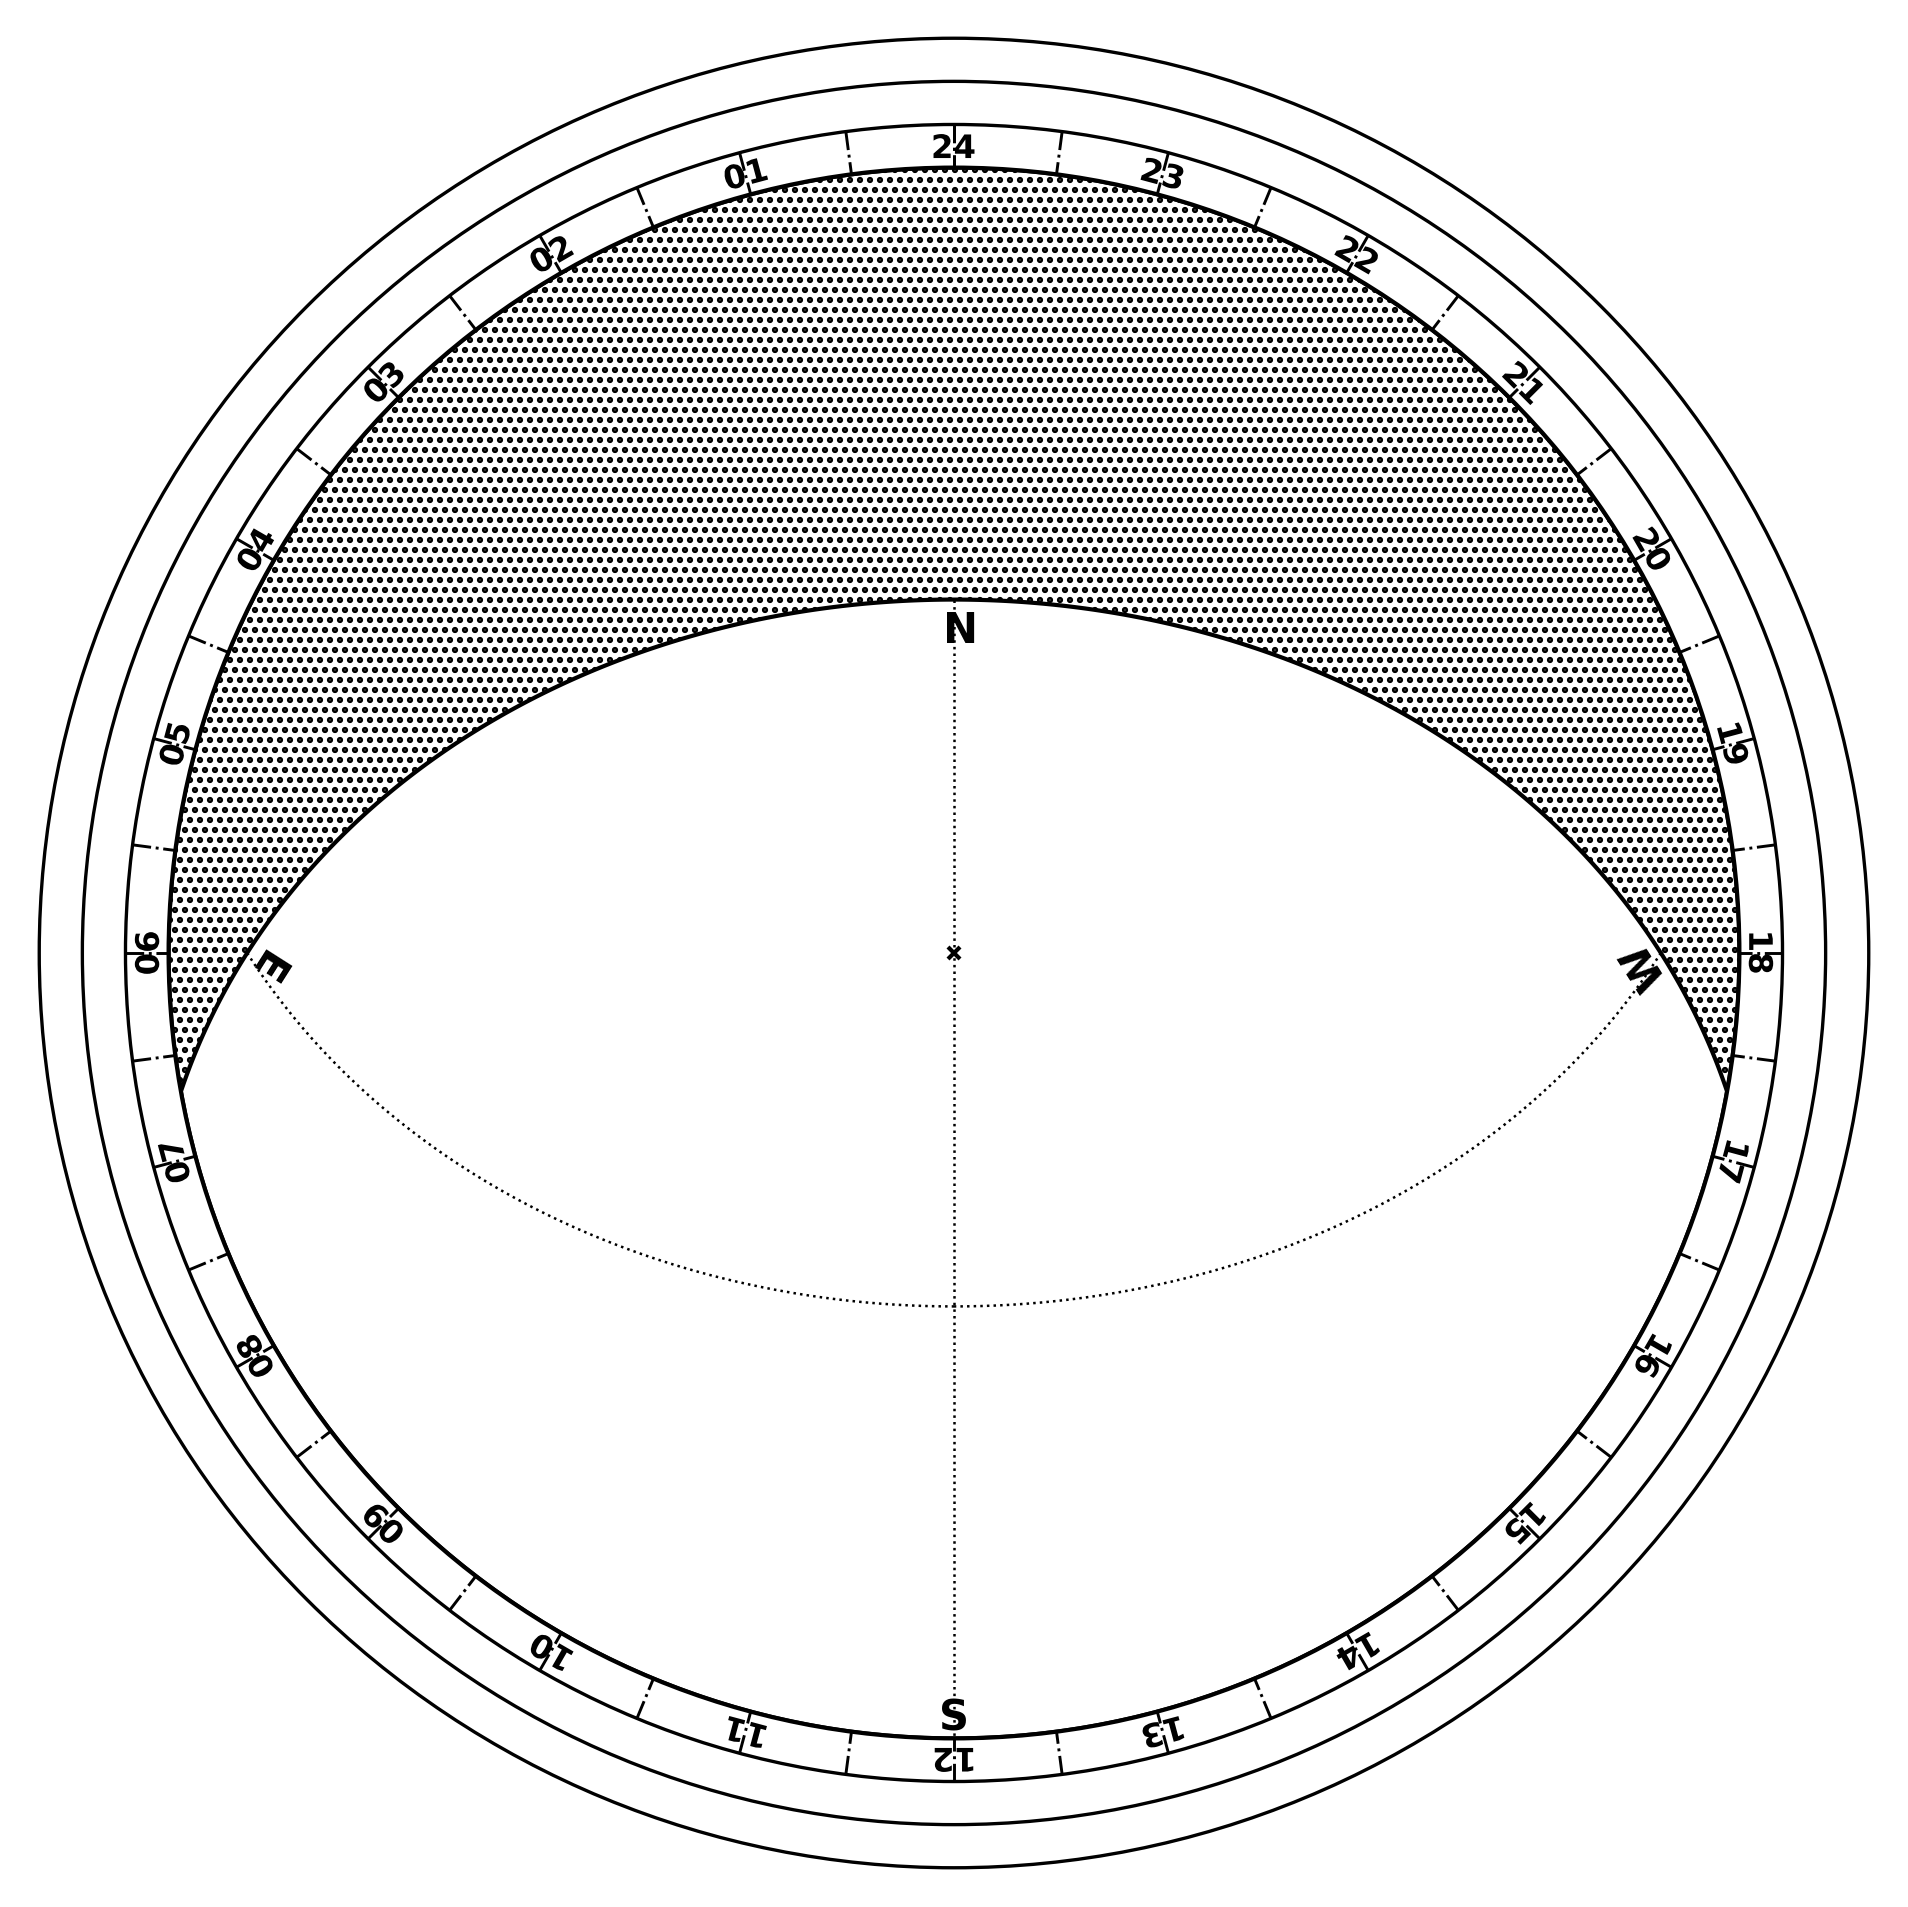

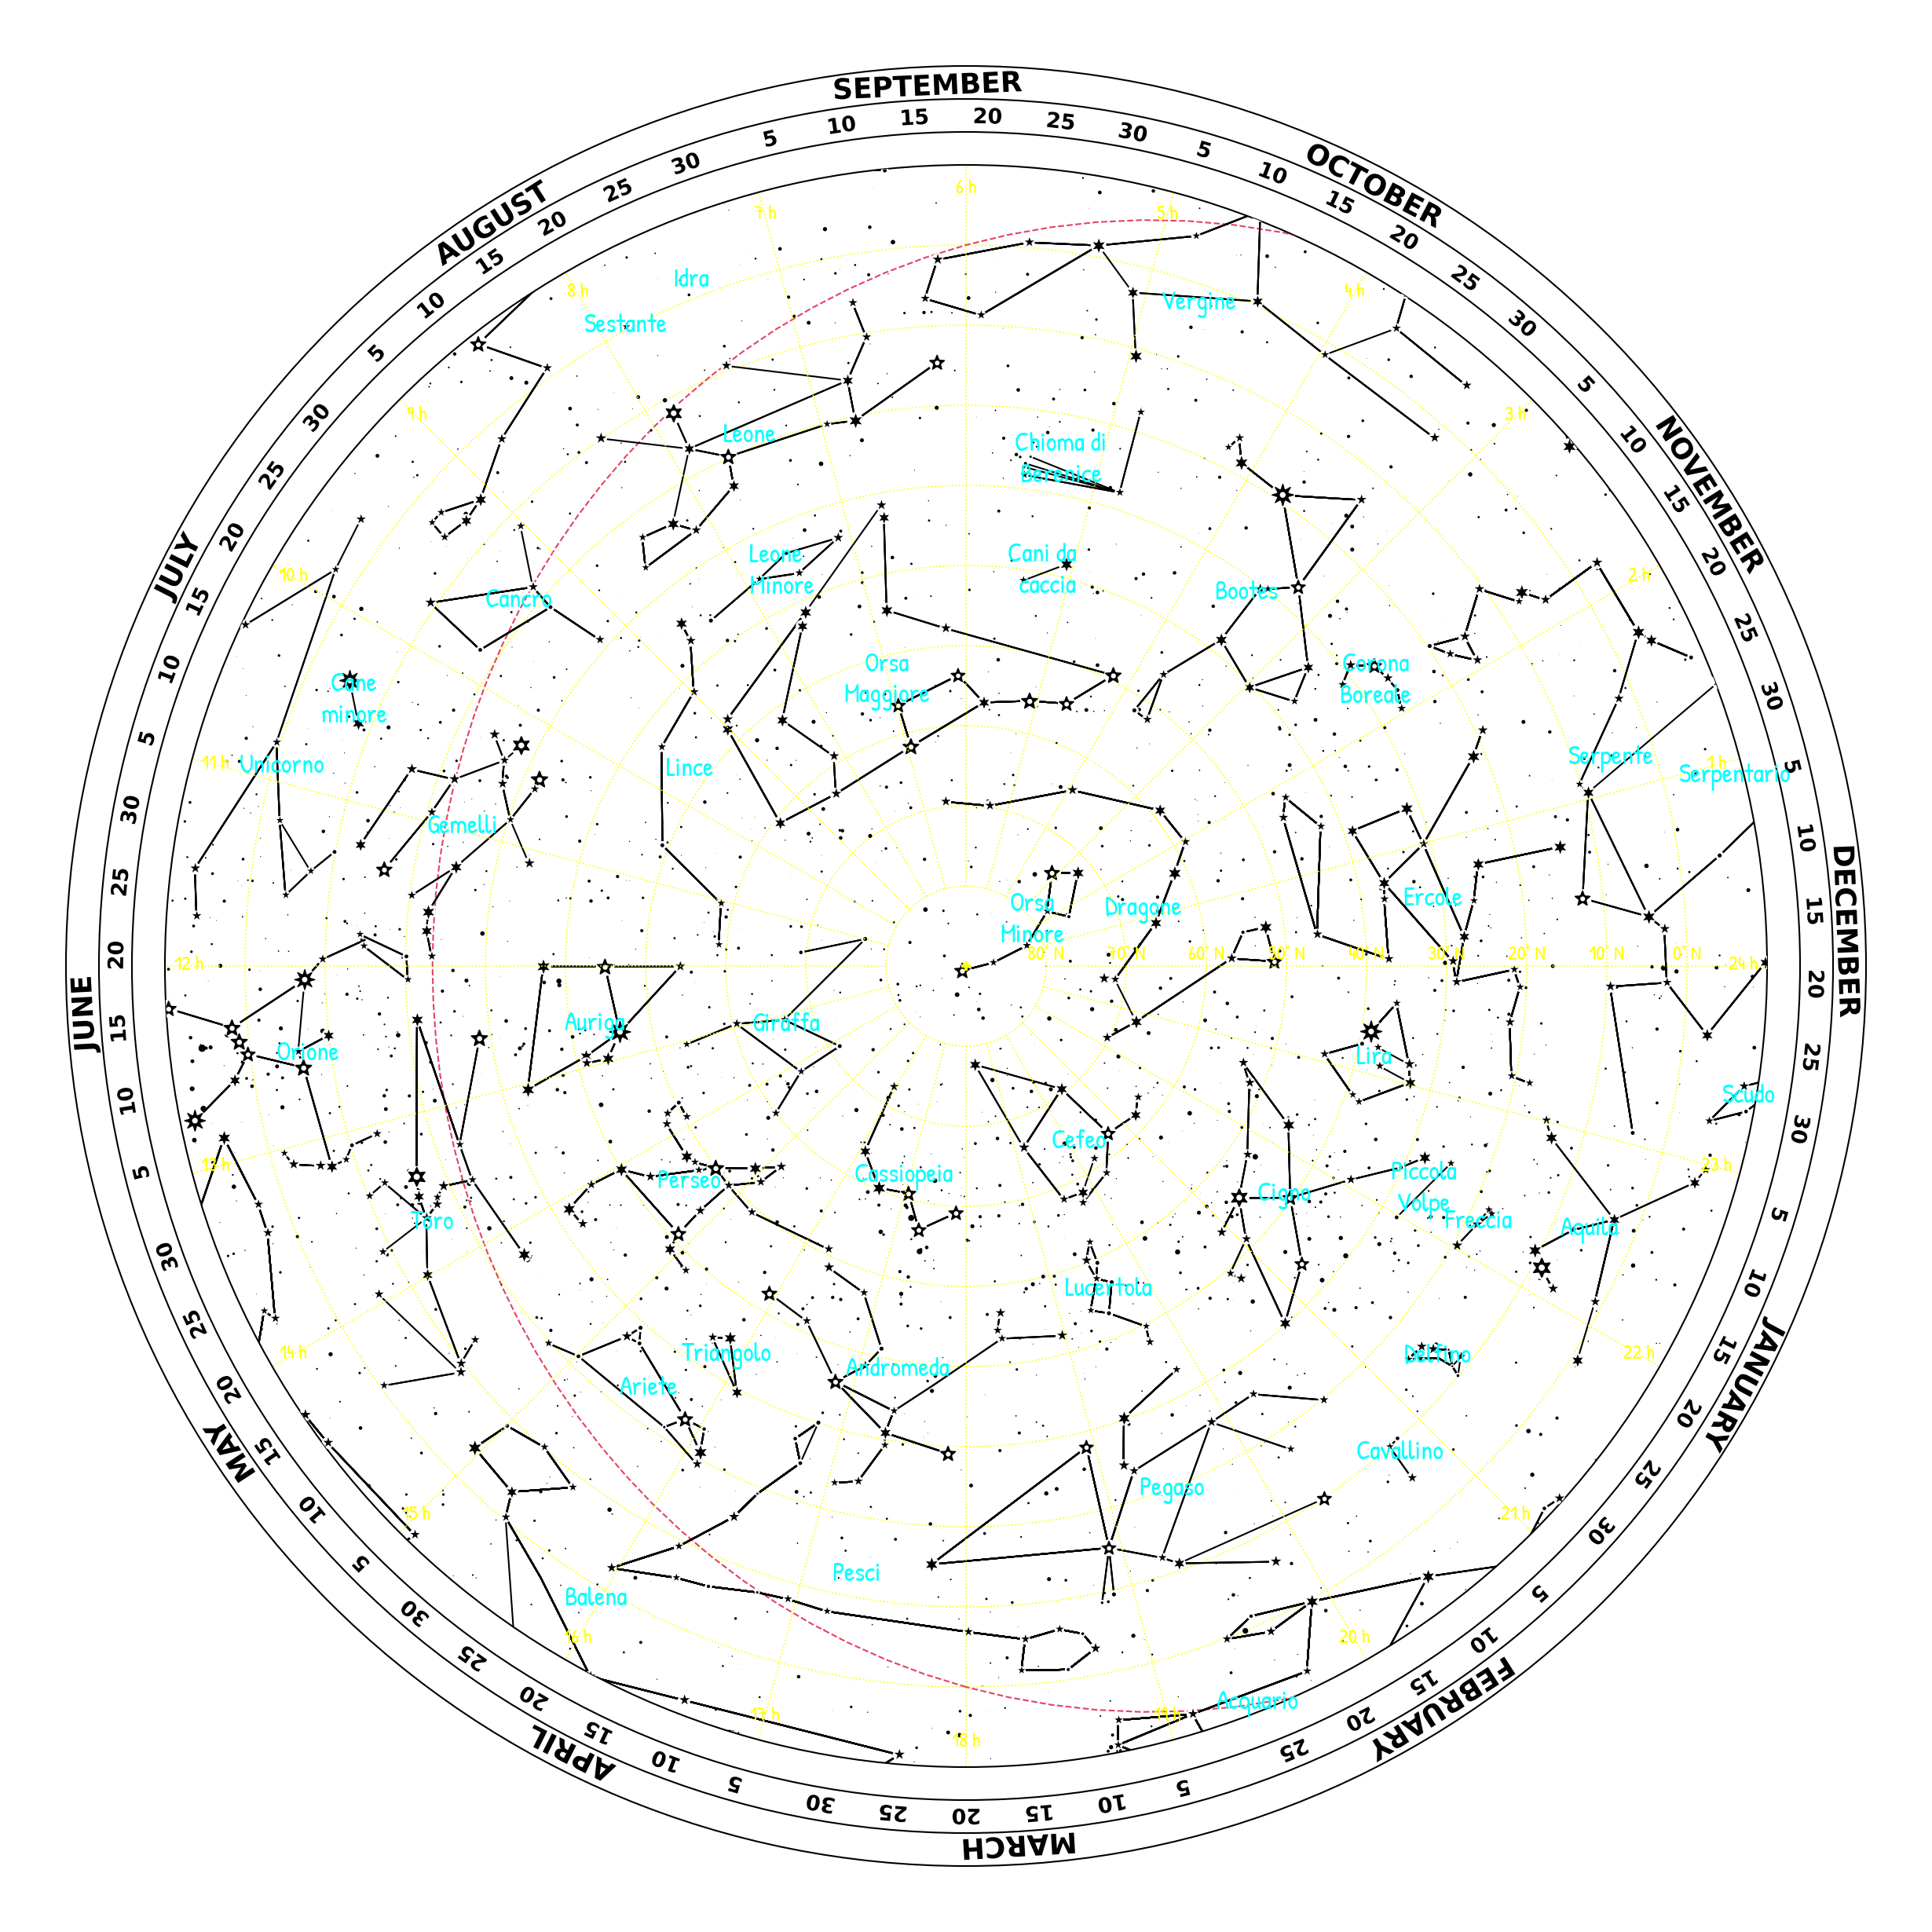

In [6]:
harey.set_flags({'GRID':True, 'SIS_SCRIPT':True, 'CON_LINES':True, 'CON_NAMES':True})
harey.create_planisphere(lat='45 N', MARK_CENTER=True, font_sizes=(6,8))

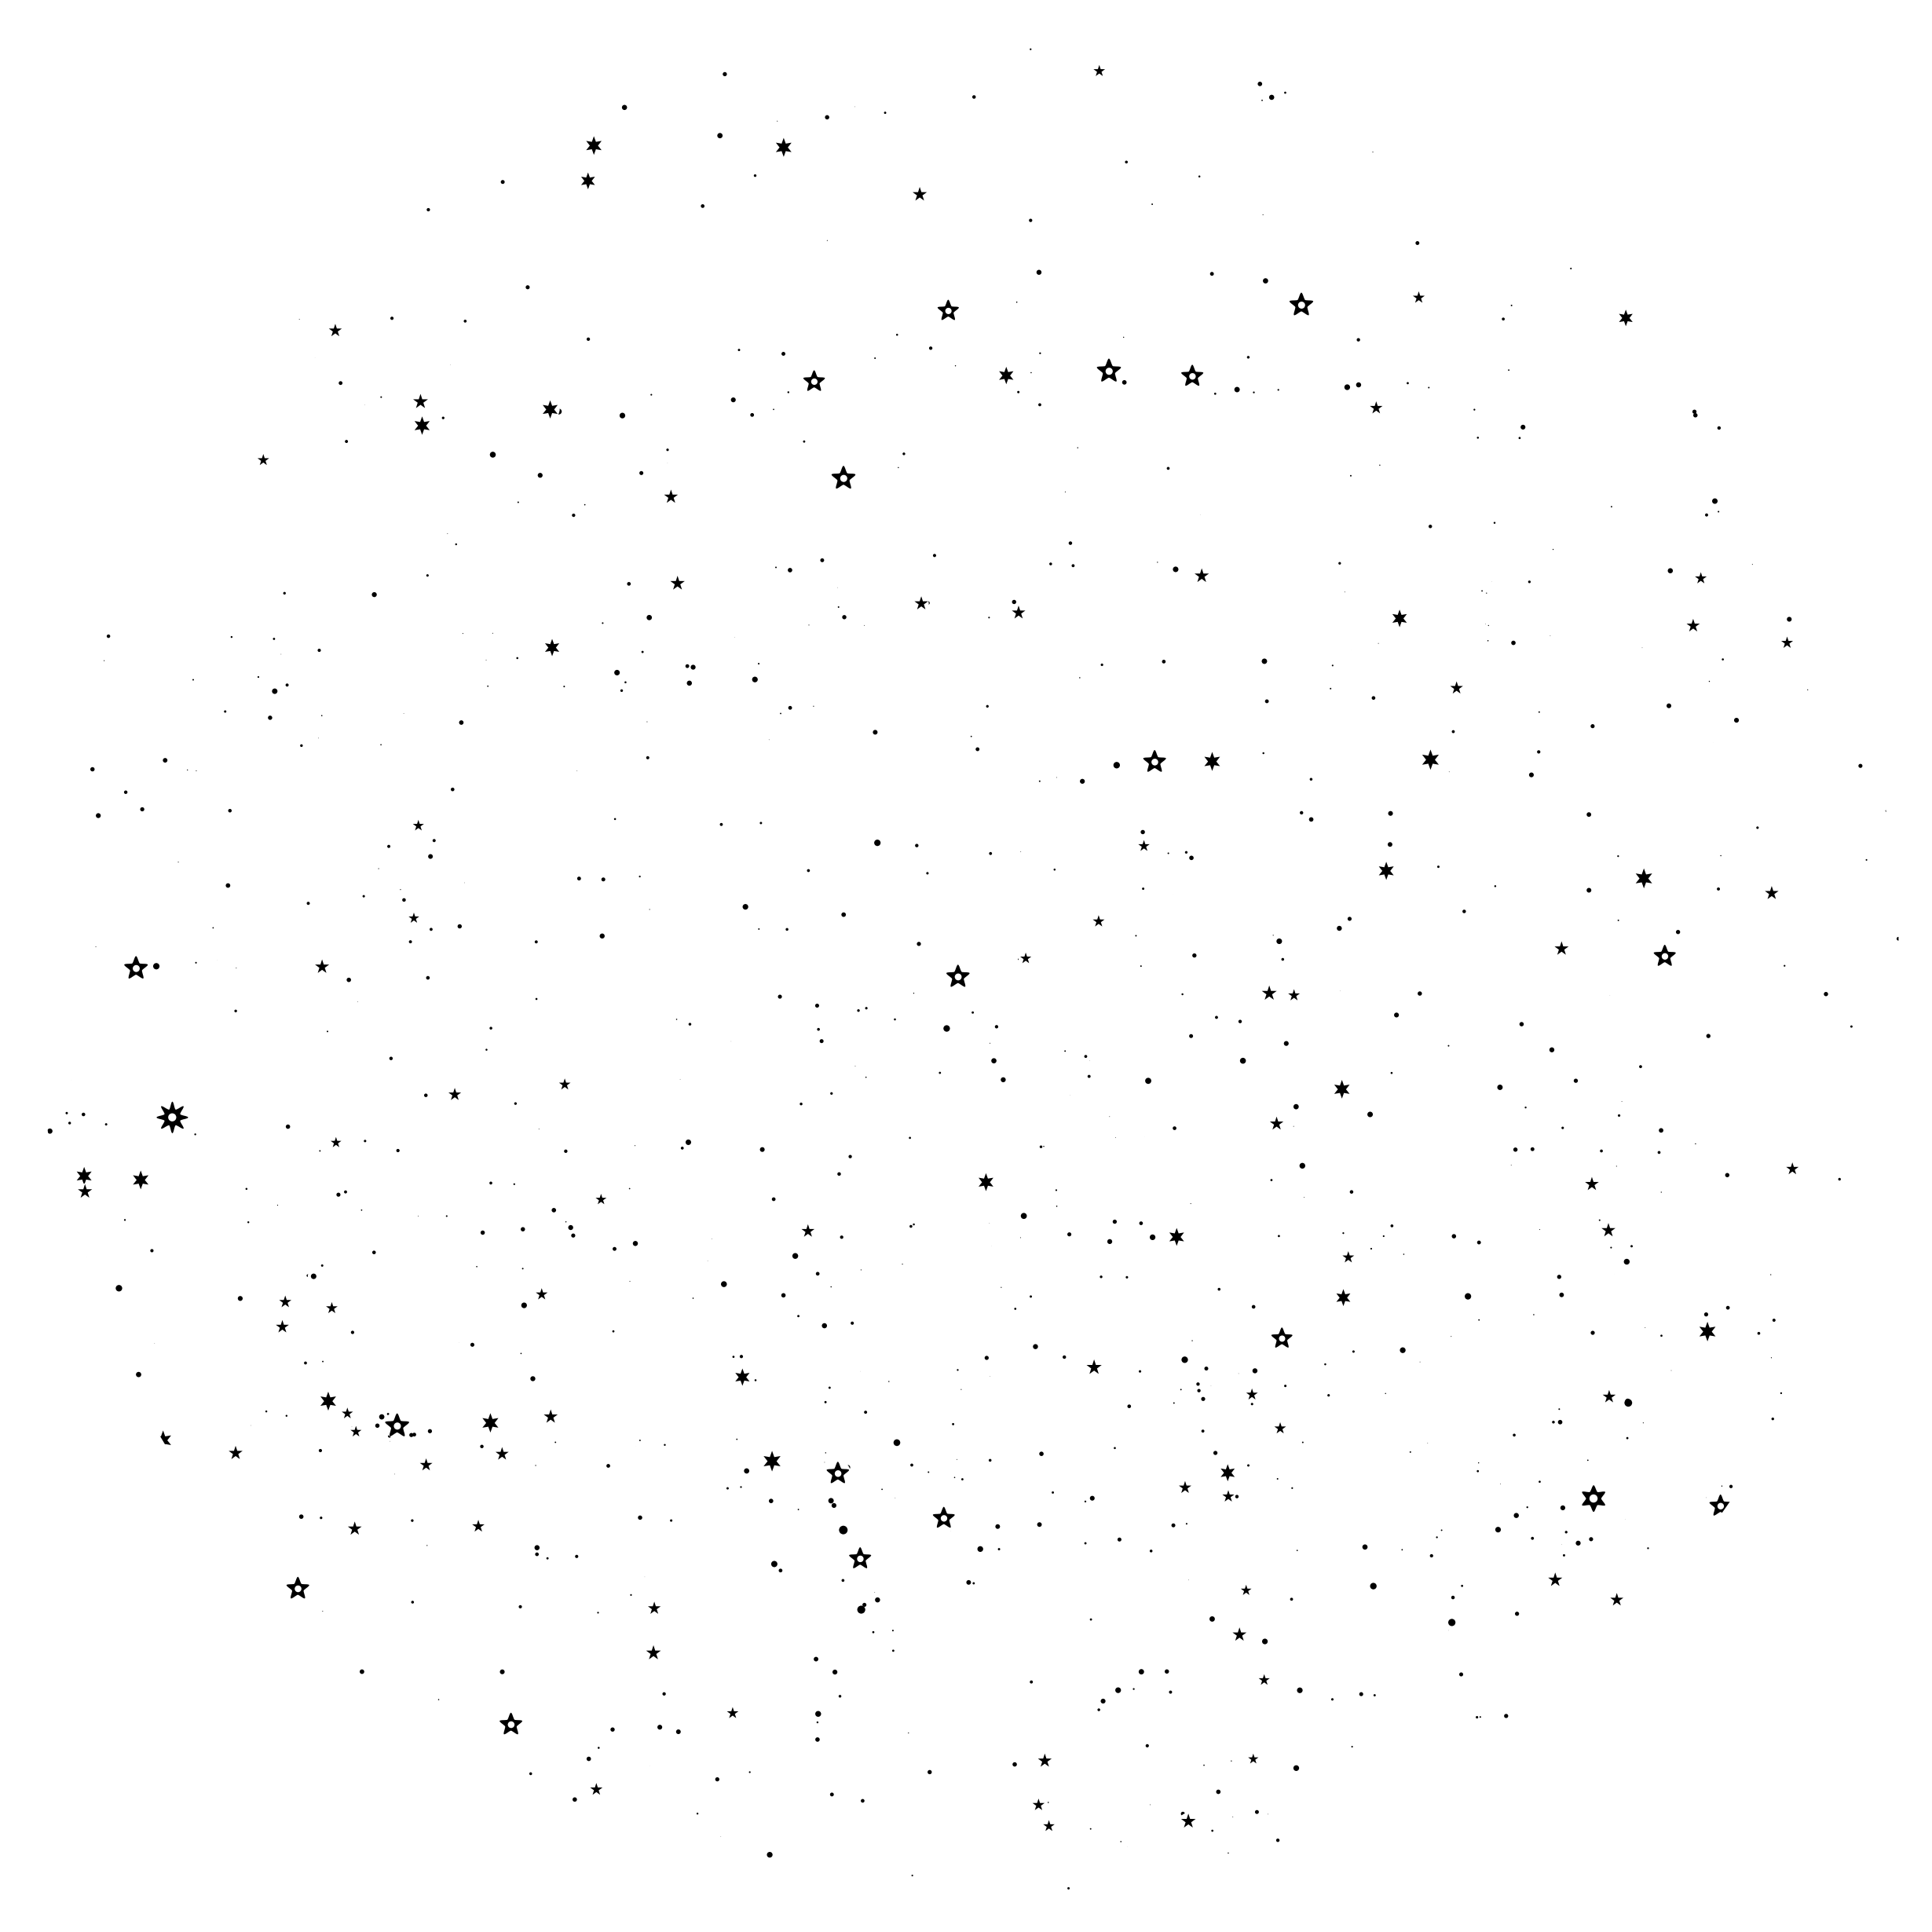

In [7]:
harey.polar_map()

In [8]:
from datetime import datetime

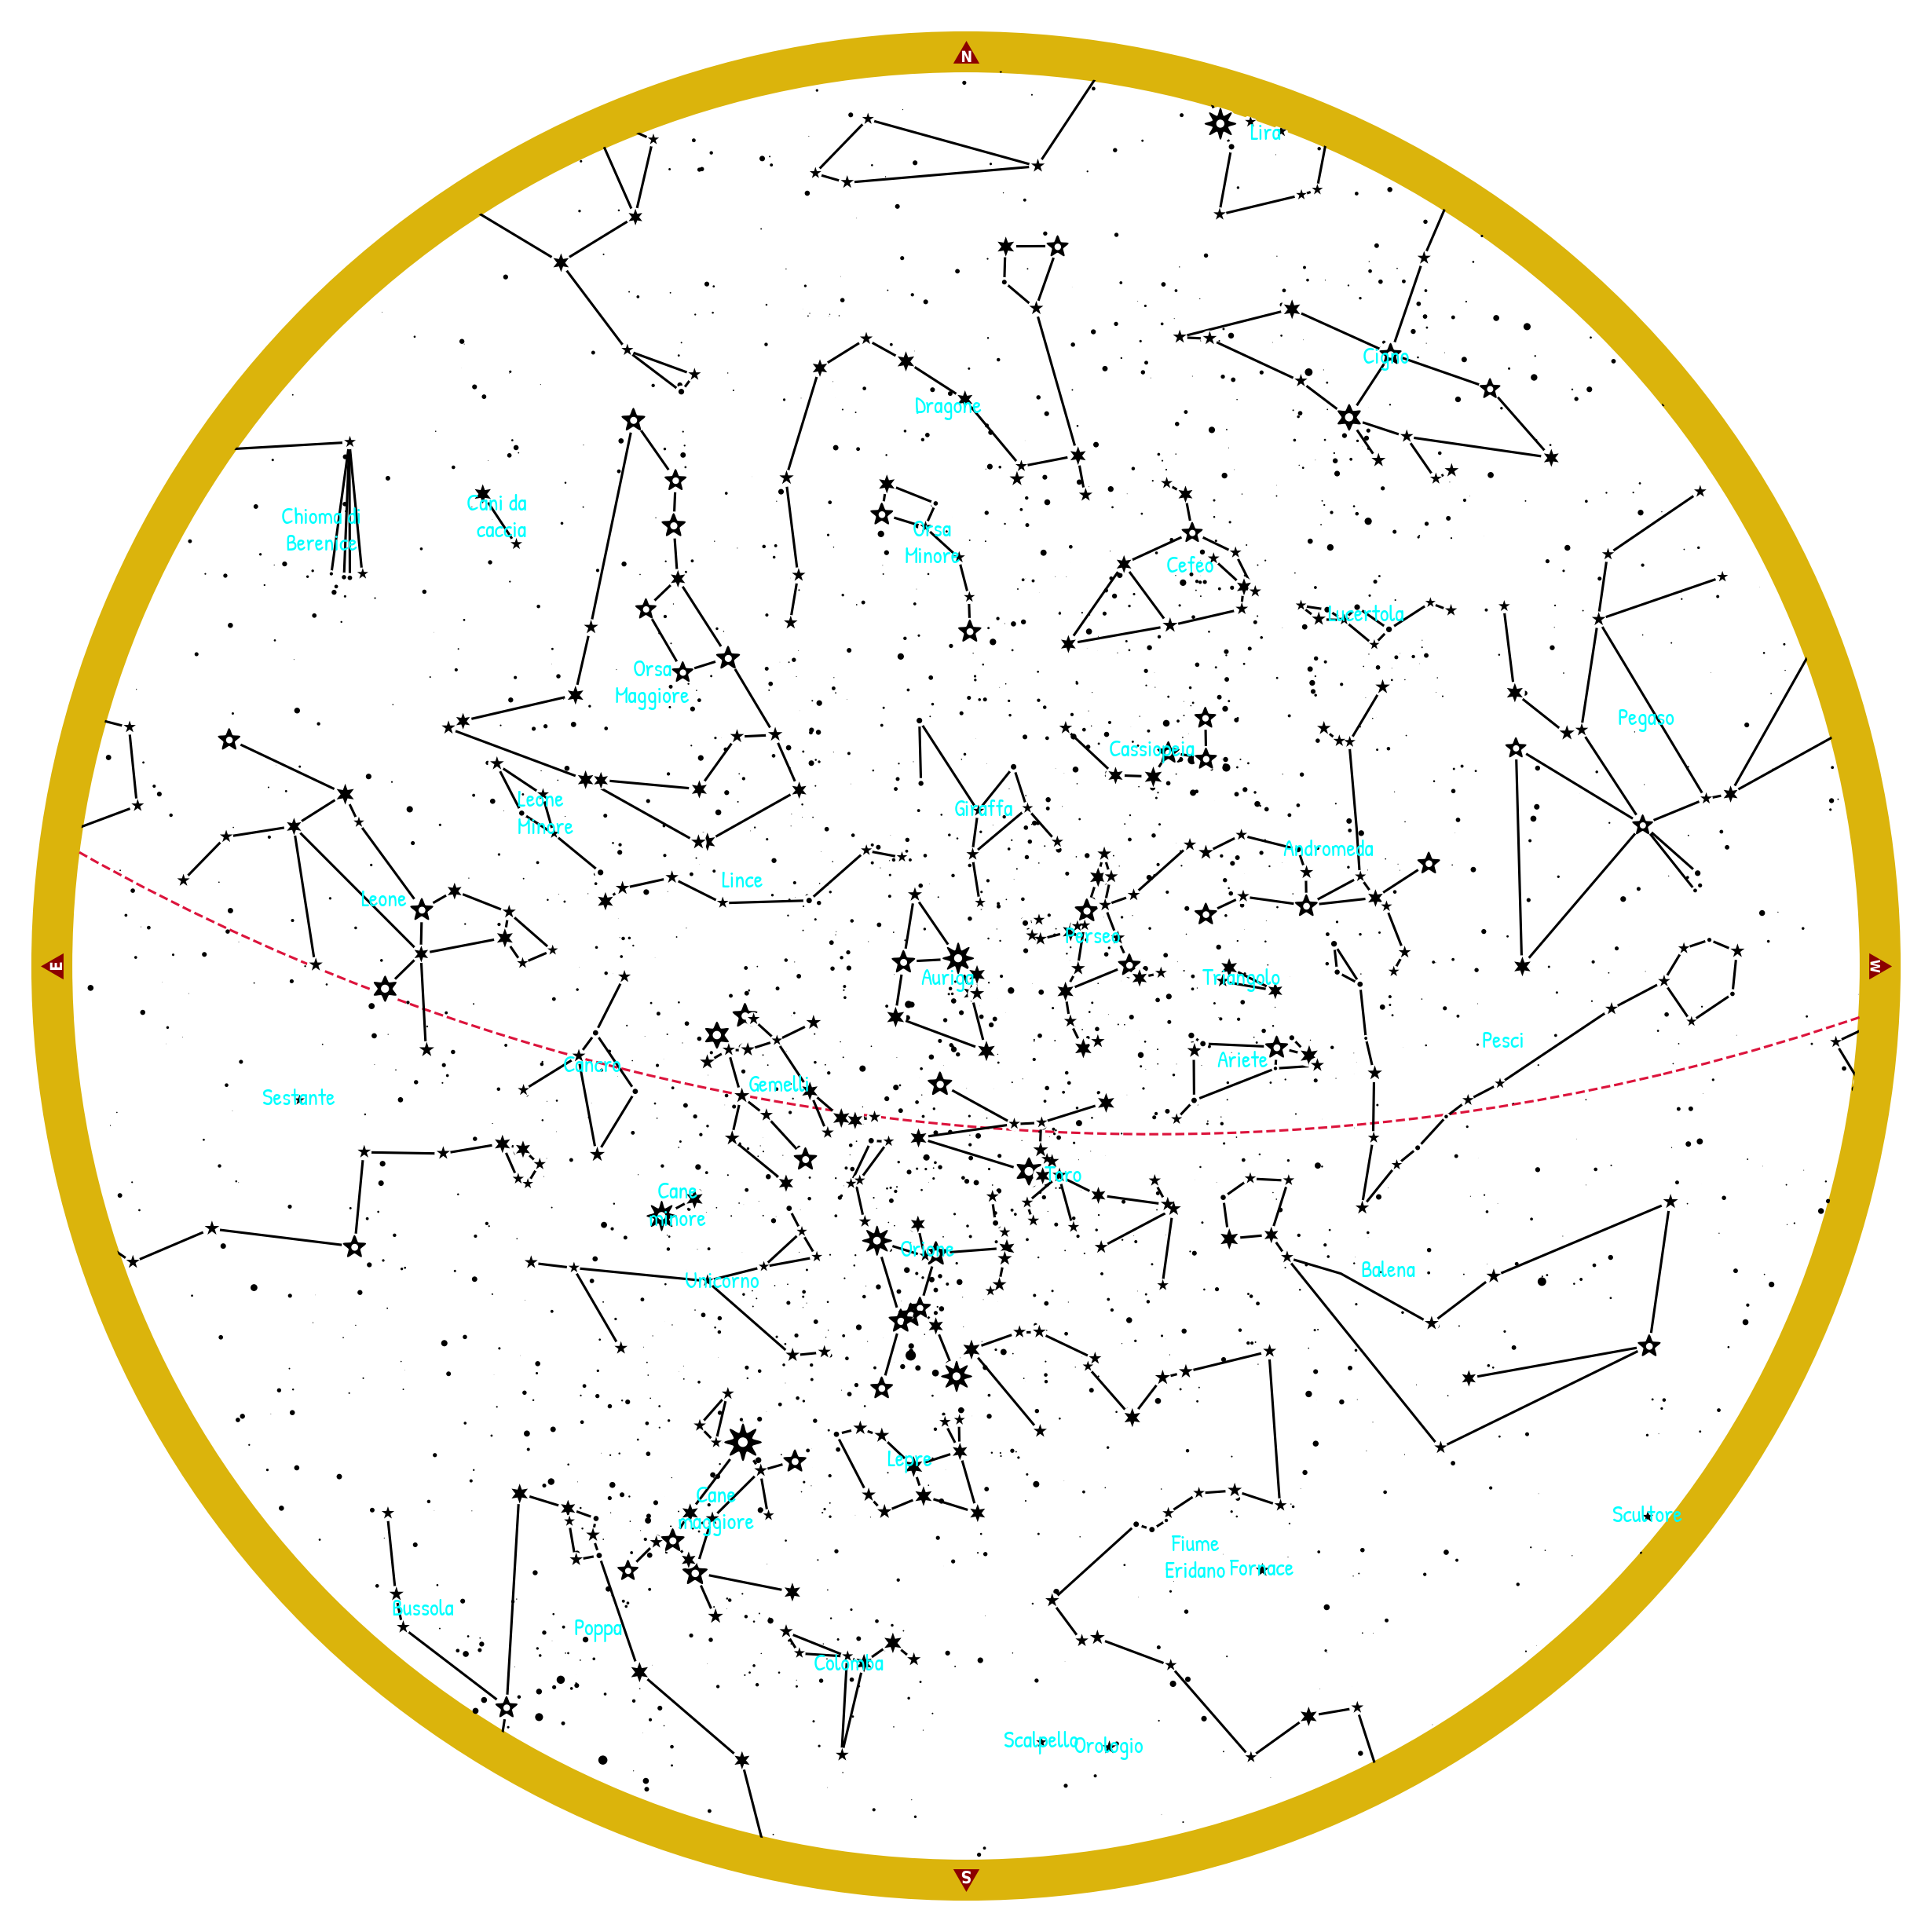

In [9]:
observer = harey.Observer('45 N', '11 E')
observer.at_time_utc(datetime(2025, 12, 1, 0, 0))
harey.set_flags({'CON_NAMES':True, 'CON_LINES':True, 'SIS_SCRIPT':True})
harey.plot_sky_view(observer)

In [10]:
from matplotlib.font_manager import FontProperties

In [11]:
font = FontProperties(fname='fonts/TheWalkyr.ttf')
font.get_name()

'The Walkyr'

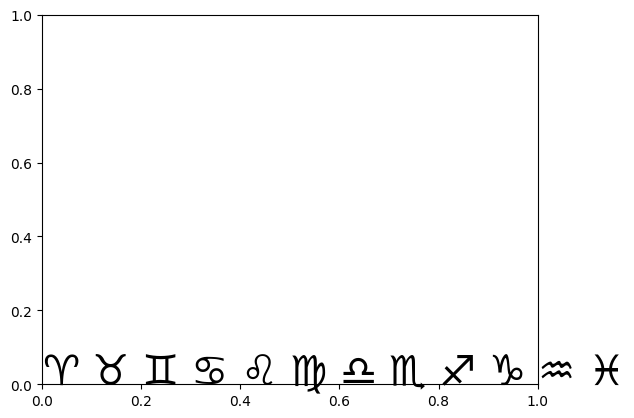

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

for i, z in enumerate(['\u2648', '\u2649', '\u264A', '\u264B', '\u264C', '\u264D', '\u264E', '\u264F', '\u2650', '\u2651', '\u2652', '\u2653']):
    plt.text(0.1*i,0, z, fontsize=30)


In [13]:
a = ['a', 'b', 'c', 'd']

for i, c in zip(range(len(a)), a):
    print(i,c)

0 a
1 b
2 c
3 d


In [14]:
for i,c in zip(reversed(range(len(a)), reversed(a))):
    print(i,c)

TypeError: reversed expected 1 argument, got 2